# SPRINT 1: DATA EXPLORATION AND RESEARCH QUESTIONS

OBJETIVOS:

1. Cargar el dataset: código facilitado
2. Explorar el dataset: código facilitado
3. Normalizar la información: completar código
4. Plantear preguntas de investigación relevantes relacionadas con el aprendizaje no supervisado: completar texto
5. Reflexión final sobre técnicas de reducción de datos: completar texto





In [1]:
# import some libraries
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# seaborn is a layer on top of matplotlib which has additional visualizations -
# just importing it changes the look of the standard matplotlib plots.
# the current version also shows some warnings which we'll disable.
import seaborn as sns
sns.set(style="white", color_codes=True)
import warnings
warnings.filterwarnings("ignore")

## 1.- Load Data





In [2]:
# get data and show some records

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
# load dataset into Pandas DataFrame
data = pd.read_csv(url, names=['sepal length','sepal width','petal length','petal width','target'])


#data = data.drop('Id', axis=1) # get rid of the Id column - don't need it
data.sample(5)

,sepal length,sepal width,petal length,petal width,target
58,6.6,2.9,4.6,1.3,Iris-versicolor
89,5.5,2.5,4.0,1.3,Iris-versicolor
104,6.5,3.0,5.8,2.2,Iris-virginica
125,7.2,3.2,6.0,1.8,Iris-virginica
99,5.7,2.8,4.1,1.3,Iris-versicolor


## 2a.- Explore Data

In [3]:
# split data into features (X) and labels (y)
X = data.iloc[:,0:4]
y = data.iloc[:,-1]

print("\n Caracteristicas \n")
print(X.sample(5))
print("\n Target \n")
print(y.sample(5))


 Caracteristicas 

     sepal length  sepal width  petal length  petal width
134           6.1          2.6           5.6          1.4
20            5.4          3.4           1.7          0.2
39            5.1          3.4           1.5          0.2
56            6.3          3.3           4.7          1.6
74            6.4          2.9           4.3          1.3

 Target 

140     Iris-virginica
50     Iris-versicolor
0          Iris-setosa
63     Iris-versicolor
34         Iris-setosa
Name: target, dtype: object


## 2b.- Visualize Data


In [4]:
data["target"].value_counts()


target
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

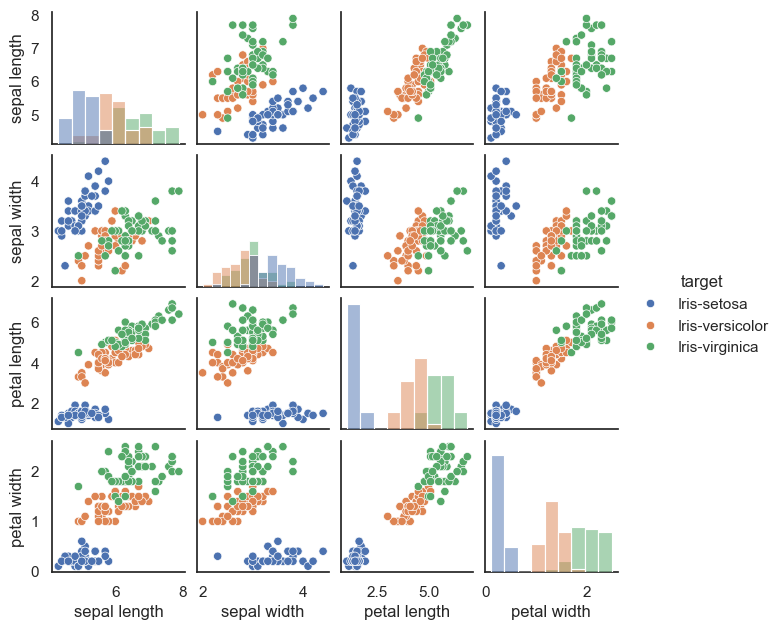

In [5]:
sns.pairplot(data, hue="target", diag_kind="hist", size=1.6);


Versicolor y Virginica son muy similares, sera muy dificil generar un algoritmo de clustering que las pueda separar, pero vamos a intentarlo!!



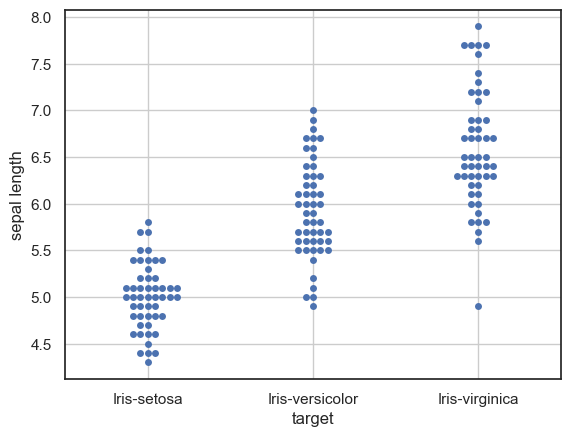

In [6]:
sns.swarmplot(x="target", y="sepal length", data=data)
plt.grid()

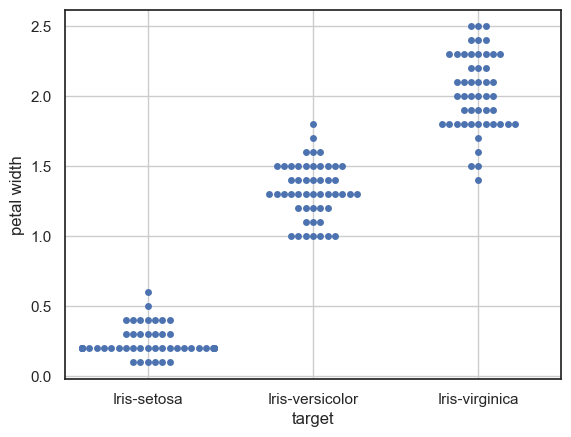

In [7]:
sns.swarmplot(x="target", y="petal width", data=data)
plt.grid()

## 3.- Feature Scaling
Los datos estan desbalanceados por ejemplo Sepal Lenght es aproximadamente 4 veces mas grande que Petal Width, por lo tando recomiendo escalar los valores. de lo contrario, las características más grandes dominarán a las demás en la agrupación, etc.

In [8]:
from sklearn import preprocessing

scaler = preprocessing.StandardScaler()

X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled_array, columns = X.columns)

X_scaled.sample(5)

,sepal length,sepal width,petal length,petal width
89,-0.416010,-1.281972,0.137236,0.133226
133,0.553333,-0.587764,0.762759,0.396172
119,0.189830,-1.976181,0.705893,0.396172
147,0.795669,-0.124958,0.819624,1.053537
102,1.522676,-0.124958,1.217684,1.185010


In [9]:
# Creamos el DataFrame con los datos reescalados
Data_scaled = pd.concat([X_scaled, y], axis=1)
Data_scaled

,sepal length,sepal width,petal length,petal width,target
0,-0.900681,1.032057,-1.341272,-1.312977,Iris-setosa
1,-1.143017,-0.124958,-1.341272,-1.312977,Iris-setosa
2,-1.385353,0.337848,-1.398138,-1.312977,Iris-setosa
3,-1.506521,0.106445,-1.284407,-1.312977,Iris-setosa
4,-1.021849,1.263460,-1.341272,-1.312977,Iris-setosa
...,...,...,...,...,...
145,1.038005,-0.124958,0.819624,1.447956,Iris-virginica
146,0.553333,-1.281972,0.705893,0.922064,Iris-virginica
147,0.795669,-0.124958,0.819624,1.053537,Iris-virginica
148,0.432165,0.800654,0.933356,1.447956,Iris-virginica


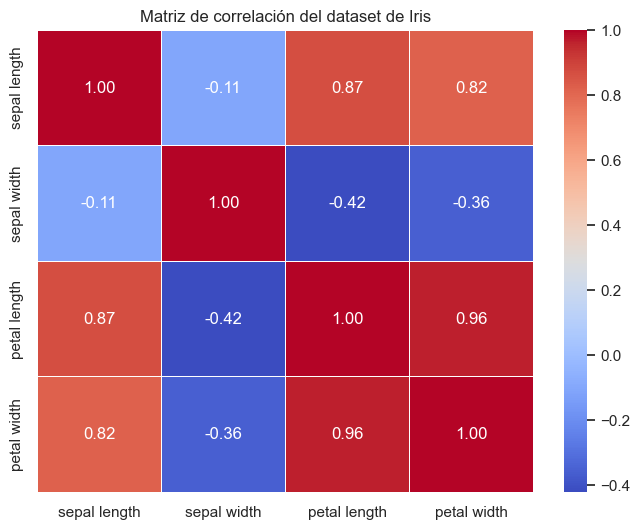

In [10]:
# Evaluamos la correlación entre las variables
corr = Data_scaled.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Matriz de correlación del dataset de Iris")
plt.show()

## 4.- Research questions

--------------------------------------------------------------------
INCORPORA AQUI LAS PREGUNTAS DE INVESTIGACIÓN

* ¿Qué relación hay entre longitud y anchura de pétalos y sépalos? (Asociación)
* ¿Existe alguna relación entre el tamaño de los sépalos y los pétalos? (Asociación)
* ¿Qué posibles conjuntos podemos agrupar en función de las características de los pétalos y los sépalos? (Agrupación)

* ¿La agrupación de los datos mejora tras realizar la PCA?
* ¿Qué beneficios e inconvenientes presenta la reducción de dimensionalidad para este dataset?
* ¿Podemos mejorar los resultados empleando algún otro algoritmo de clustering?

* ¿Cómo clasificamos los outliers del dataset?
* ¿Qué implica la presencia de outliers, son datos erroneos o sucesos atípicos?
--------------------------------------------------------------------

## 5.- Reflexión final técnicas de reducción de dimensionalidad

---------------------------------------------------
INCORPORA AQUÍ TU REFLEXIÓN SOBRE ESTE PUNTO

Si analizamos los datos sin etiquetar tras el reescalado, vemos que algunas relaciones son claramente lineales, como el largo y ancho de los sépalos, u otras que aunque no sea tan claro, sí parecen tener cierta linealidad en su relación, como la longitud del pétalo y del sépalo. Otras, sin embargo, no parecen en absoluto lineales, como el ancho y largo del pétalo. 

Por tanto, para capturar estas relaciones, si pretendemos emplear una reducción de dimensionalidad, deberíamos emplear técnicas diferentes. Por ejemplo, para las relaciones lineales, PCA sería una buena opción, ya que permitiría agrupar dicha información en una menor cantidad de variables; mientras que para las no lineales, otros algoritmos no lineales, tales como t-SNE o UMAP, podrían ser más adecuados, o de lo contrario nos enfrentaríamos a una pérdida sustancial de información.

Por otra parte, una evaluación de la correlación de variables indica alta correlación entre ellas, especialmente entre tres de las cuatro variables, lo que parece indicar que una reducción de dimensión de 4 a 2 sería apropiado.

----------------------------------------------------


# SPRINT 2: CLUSTERING

OBJETIVOS:
1. Practicar método silueta
2. Practicar método del codo
3. Practicar modelo clustering k-means
4. Añadir conclusiones

## 1.- Silhouette

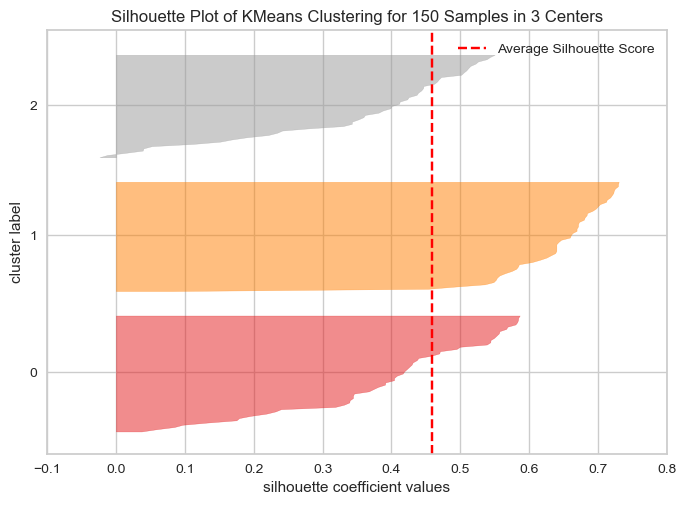

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 150 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [11]:
# Instantiate the clustering model and visualizer
#pip install yellowbrick

from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

nclusters = 3
seed = 0

model = KMeans(n_clusters=nclusters
            , init = 'k-means++'
            , max_iter=500
            , n_init=10
            , random_state=seed)


visualizer = SilhouetteVisualizer(model)

visualizer.fit(X_scaled)    # Fit the data to the visualizer
visualizer.show()    # Draw/show/show the data

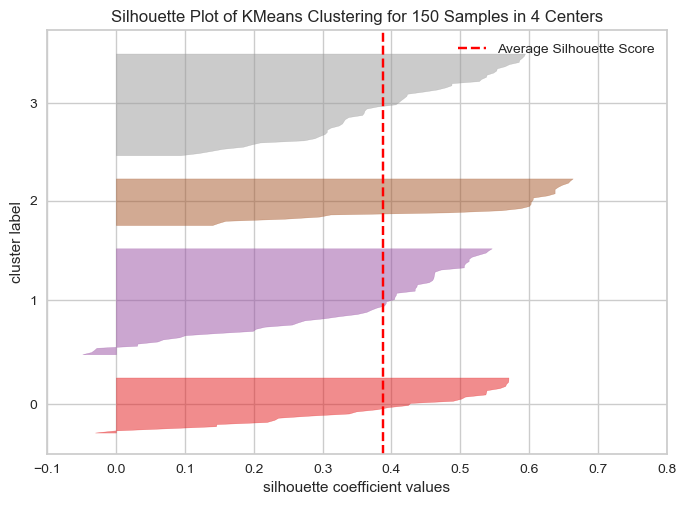

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 150 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [12]:
# Instantiate the clustering model and visualizer
#pip install yellowbrick


from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

nclusters = 4
seed = 0

model = KMeans(n_clusters=nclusters
            , init = 'k-means++'
            , max_iter=500
            , n_init=10
            , random_state=seed)


visualizer = SilhouetteVisualizer(model)

visualizer.fit(X_scaled)    # Fit the data to the visualizer
visualizer.show()    # Draw/show/show the data

## 2.- Elbow

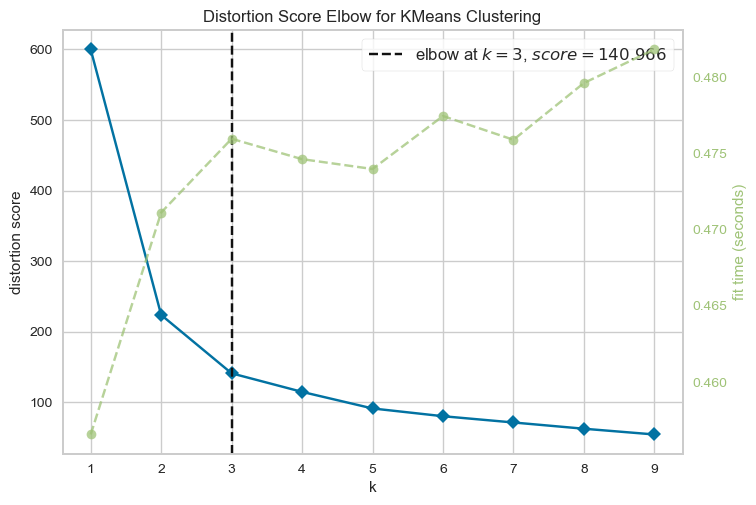

In [13]:
#from sklearn import datasets
from yellowbrick.cluster import KElbowVisualizer

# Instantiate the clustering model and visualizer

seed = 0

km = KMeans(init = 'k-means++'
            , max_iter=500
            , n_init=10
            , random_state=seed)


visualizer = KElbowVisualizer(km, k=(1,10))

visualizer.fit(X_scaled)        # Fit the data to the visualizer
visualizer.show()               # Finalize and render the figure
k = visualizer.elbow_value_

## 3.- K-Means
Intente agrupar los datos en 4D y ver si puede reproducir los clústeres reales. Es decir, imagine que no tenemos las etiquetas de especies en estos datos y queremos dividir las flores en especies. podría establecer un número arbitrario de grupos e intentar dividirlos en grupos similares. Sabemos que hay 3 especies, así que encontremos 3 especies y veamos si las predicciones para cada punto coinciden con la etiqueta en y, por otro lado sabemos que por el metodo de las siluetas y elbow, la cantidad de clusters recomendada es 3

In [14]:
from sklearn.cluster import KMeans

nclusters = k
seed = 42

#DESARROLLE AQUI EL METODO DE KMeans utilizando la libreia KMeans.

km = KMeans( n_clusters = nclusters, random_state = seed, init='k-means++', n_init=10, max_iter=500)
km.fit(X_scaled)

# Predecir el clúster al que pertenece cada punto de datos
y_cluster_kmeans = km.predict(X_scaled)

print("\n Caracteristicas \n")
print(X_scaled)

print("\n\n\n Clusters \n")
print(y_cluster_kmeans)


 Caracteristicas 

     sepal length  sepal width  petal length  petal width
0       -0.900681     1.032057     -1.341272    -1.312977
1       -1.143017    -0.124958     -1.341272    -1.312977
2       -1.385353     0.337848     -1.398138    -1.312977
3       -1.506521     0.106445     -1.284407    -1.312977
4       -1.021849     1.263460     -1.341272    -1.312977
..            ...          ...           ...          ...
145      1.038005    -0.124958      0.819624     1.447956
146      0.553333    -1.281972      0.705893     0.922064
147      0.795669    -0.124958      0.819624     1.053537
148      0.432165     0.800654      0.933356     1.447956
149      0.068662    -0.124958      0.762759     0.790591

[150 rows x 4 columns]



 Clusters 

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 2 2 0 2 2 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2
 2 0 0 0 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0

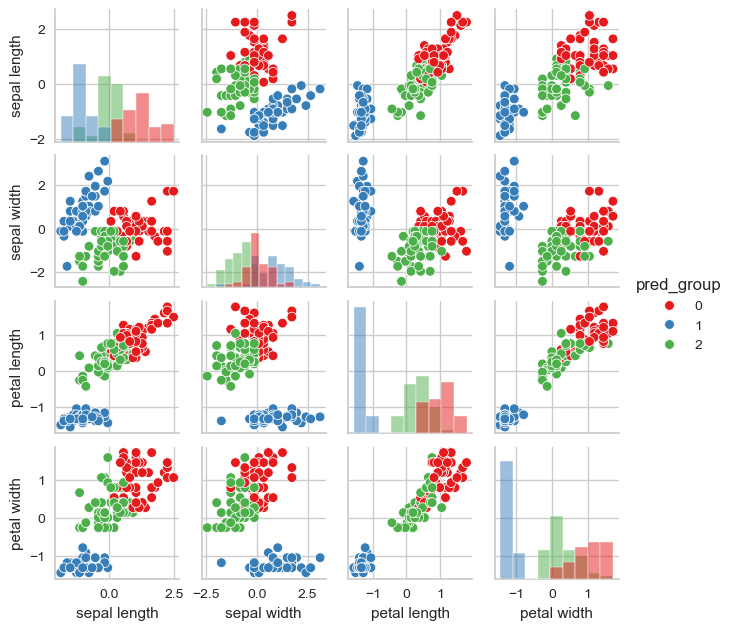

In [15]:
#Visualizamos los datos de nuestro modelo KMeans
pred_data = X_scaled.copy()
pred_data['pred_group'] = y_cluster_kmeans
sns.pairplot(pred_data, hue= 'pred_group', diag_kind="hist", size=1.6, palette= 'Set1')

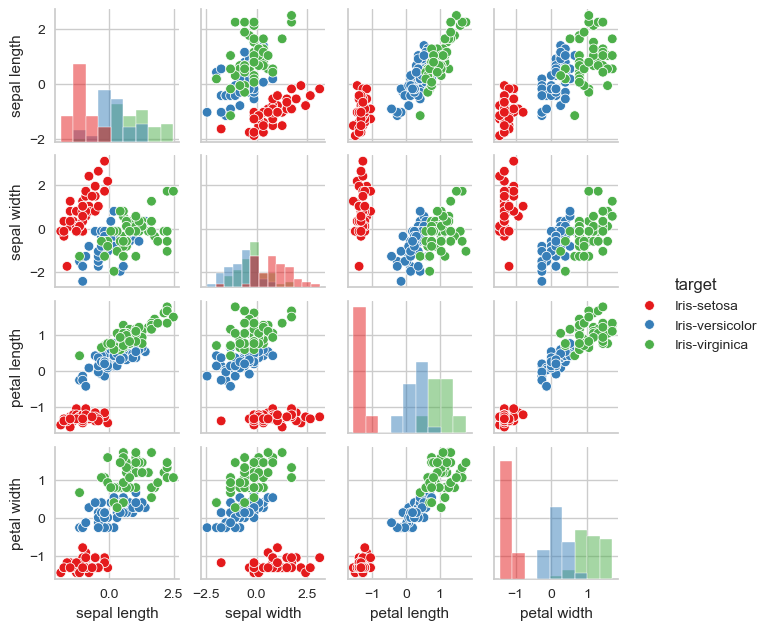

In [16]:
#Comparamos con los resultados originales reescalados
sns.pairplot(Data_scaled, hue= 'target', size= 1.6, palette= 'Set1', diag_kind="hist")

## 4.- Investigación:
Una vez que hayas aplicado técnicas de clustering al conjunto de datos, ¿cómo podrías evaluar si los clusters obtenidos son realmente representativos y bien formados? Investiga y describe métricas que permitan medir la calidad de los clusters, como la distancia intra-cluster (cohesión) y la distancia inter-cluster (separación). ¿Qué valores de estas métricas indicarían un buen resultado y por qué?

--------------------------------------------------------------
Añade aquí tus hallazgos

Medir la calidad de un clúster

Vemos en el proceso de análisis de los datos mediante el método de la silueta cómo el resultado es óptimo para la presencia de tres subgrupos. En el caso de 4 grupos aparecen algunos valores negativos, lo que indica clasificaciones claramente erroneas, además de que el valor promedio del score de la silueta disminuye. Por ende esto nos indica que deberíamos emplear 3 subconjuntos para el proceso de clustering. Sin embargo, el valor máximo obtenido es inferior a 0.5, lo que podría indicar cierto solapamiento entre grupos y por tanto la dificultad para clasificarlos.

Empleando el método del codo, el mejor valor de subconjuntos posibles también es 3, coincidiendo con lo obtenido en el método de la silueta. 

Una medida de calidad de un clustering es una función que recibe un clustering C
sobre (X,d) (donde d es una función de distancia sobre X) y devuelve un número real no negativo.

En este caso podríamos emplear dos tipos de medidas, las de validación interna, que emplean unicamente los datos incorporador en el propio conjunto de datos empleado para el proceso de clustering, o la validación externa, donde se cruzan los datos con otros conjuntos con los que poder generar un proceso de validación, como por ejemplo en este caso, los datos iniciales que incluyen la clasificación.

Como medidas internas, tenemos medidas de cohesión, como un potencial de estres que calcula el sumatorio de distancias al cuadrado de cada punto al centroide de su cluster. Esto también puede emplearse para generar una evaluación más general de la calidad de los clusters con el denominado índice de David Bouldin, que se calcula como un coeficiente entre la media de distancia intracluster y la distancia intercluster.

* Indice de Davies Bouldin (DBI): $\text{DBI} = \frac{1}{N} \sum_{i=1}^{N} \max_{j \neq i} \left( \frac{\text{C}(g_i) + \text{C}(c_j)}{\text{S}(g_i, g_j)} \right), g_i, g_j \subset S$ siendo $g_i$ y $g_j$ dos subgrupos cualesquiera y $N$ el número de grupos.

* Donde la cohesión del subgrupo o C($g_i$): $\text{C}(g_i) = \left( \frac{1}{n_i} \sum_{j = 1}^{n_i} |x_j - c_i|\right)$ siendo $c_i$ el centroide del subgrupo $g_i$ y $n_i$ el número de elementos del subgrupo.

* Y la separación entre dos subgrupos o S($g_i$, $g_j$): $\text{S}(g_i, g_j) = |c_i - c_j|$ siendo $c_i$ y $c_j$ los centroides de los subgrupos $g_i$ y $g_j$.

Cuanto más ajustado sea el clúster y más separados estén los clústeres, más bajo será este valor, por lo que los valores más próximos a 0 son mejores. Los clústeres que estén más separados y menos dispersos generarán una mejor puntuación. 

Además de esto, podemos emplear los ya vistos métodos de elbow y silueta para evaluar el error en función del número de clusters, donde elbow tienene en cuenta únicamente el agrupamiento y cohesión de cada cluster, y el método de la silueta tiene en cuenta la relación entre cohesión y distancia.

--------------------------------------------------------------

In [17]:
# Implementamos el davies_bouldin_score para evaluar la calidad de los clusters obtenidos con KMeans
from sklearn.metrics import davies_bouldin_score

DBS = davies_bouldin_score(X_scaled, y_cluster_kmeans)
DBS

0.8354098493935598

# SPRINT 3: PCA VS CLUSTERING

OBJETIVOS

1. Practicar el análisis de componentes principales
2. Comparar PCA y CLUSTERING
3. Reflexionar y discutir sobre la presencia de outliers

## 1.- Principal Component Analysis (PCA)
Si tiene muchas característics, puede ser útil reducir algunas características, para evitar la maldición de la dimensionalidad (es decir, necesitar exponencialmente más datos para hacer predicciones precisas a medida que crece la cantidad de características). Puede hacer esto con el análisis de componentes principales (PCA), que reasigna los datos a un nuevo sistema de coordenadas (más pequeño) que trata de dar cuenta de la mayor información posible. puedes también usar PCA para visualizar los datos al reducir las # características a 2 dimensiones y hacer un diagrama de dispersión.

En este caso recomiendo usar PCA para poder visualizar los datos, ya entrenamos el modelo de K-means y tenemos los clusters identificados, ahora transformemos de 4D a 2D las caracteristicas. para solo visualizarlas en un grafico, y poder observar los CLUSTERS.

In [18]:
from sklearn.decomposition import PCA

ndimensions = 2

#Aplique un algoritmo de PCA en X_scaled, para pasar de 4 a 2 dimensiones, puede utilizar la variable ndimension

pca = PCA(n_components=ndimensions)
X_pca_array = pca.fit_transform(X_scaled)
X_pca = pd.DataFrame(X_pca_array, columns=['componente principal 1','componente principal 2'])

print(X_pca.sample(10))
explained_variance = pca.explained_variance_ratio_
print("\n\n explained_variance")
print(explained_variance)

     componente principal 1  componente principal 2
11                -2.327378                0.158587
127                1.019781                0.065543
10                -2.163487                1.070596
78                 0.662126               -0.224346
109                2.267555                1.921443
142                1.153190               -0.701326
23                -1.820412                0.106751
41                -1.871707               -2.327692
123                1.329194               -0.486761
85                 0.431783                0.855137


 explained_variance
[0.72770452 0.23030523]


In [19]:
# Entrenemos un nuevo algoritmo de KMeans con los datos de PCA
nclusters = 3
seed = 42

#Ejecutamos el modelo KMeans con los datos de PCA
km_PCA = KMeans(n_clusters=nclusters, random_state=seed, init='k-means++', n_init=10, max_iter=500)
km_PCA.fit(X_pca)

# Predecir el clúster al que pertenece cada punto de datos
y_PCA_kmeans = pd.Series(km_PCA.predict(X_pca))

# Añadimos los datos originales de la variable objetivo
finalDf = pd.concat([X_pca, data[['target']]], axis = 1)
finalDf.head()

# Anadimos los resultados predichos al DataFrame
finalDf['ClusterKmeans'] = y_PCA_kmeans
finalDf.sample(10)

,componente principal 1,componente principal 2,target,ClusterKmeans
87,1.035878,-1.392466,Iris-versicolor,0
85,0.431783,0.855137,Iris-versicolor,2
12,-2.224083,-0.709118,Iris-setosa,1
24,-2.228217,0.162186,Iris-setosa,1
55,0.384458,-0.591062,Iris-versicolor,0
3,-2.304197,-0.575368,Iris-setosa,1
89,0.275425,-1.329816,Iris-versicolor,0
114,1.464062,-0.444148,Iris-virginica,0
47,-2.398192,-0.362391,Iris-setosa,1
54,1.072594,-0.211758,Iris-versicolor,0


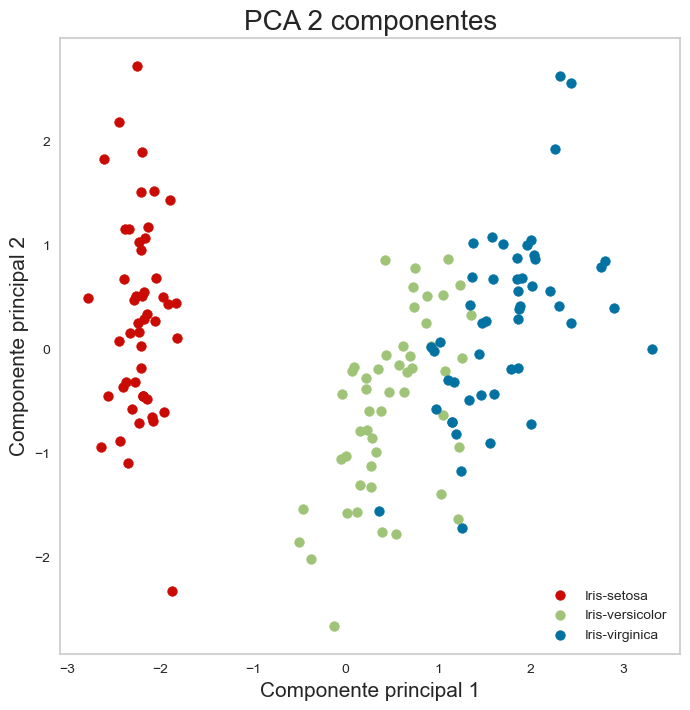

In [20]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1)
ax.set_xlabel('Componente principal 1', fontsize = 15)
ax.set_ylabel('Componente principal 2', fontsize = 15)
ax.set_title('PCA 2 componentes', fontsize = 20)
targets = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
colors = ['r', 'g', 'b']
for target, color in zip(targets,colors):
    indicesToKeep = finalDf['target'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'componente principal 1']
        , finalDf.loc[indicesToKeep, 'componente principal 2']
        , c = color
        , s = 50)
ax.legend(targets)
ax.grid()

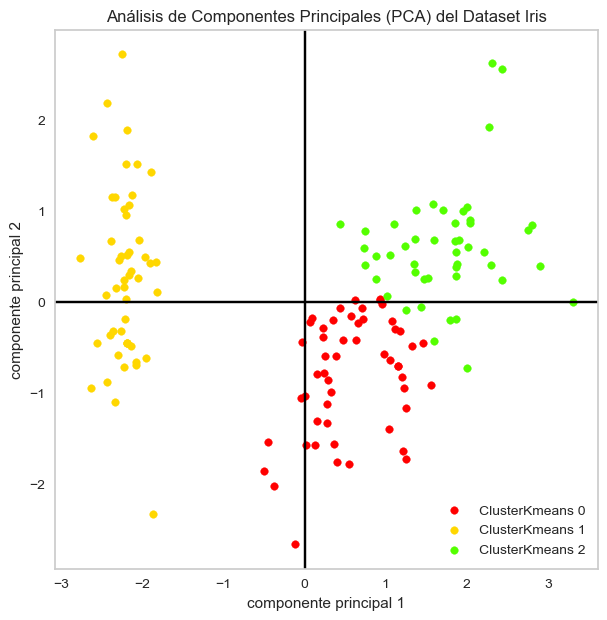

In [21]:
# so now we can make a 2d scatterplot of the clusters
# first define a plot fn

def plotData(df, groupby):
    "make a scatterplot of the first two principal components of the data, colored by the groupby field"

    # make a figure with just one subplot.
    # you can specify multiple subplots in a figure,
    # in which case ax would be an array of axes,
    # but in this case it'll just be a single axis object.
    fig, ax = plt.subplots(figsize = (7,7))

    # color map
    cmap = mpl.cm.get_cmap('prism')

    # we can use pandas to plot each cluster on the same graph.
    # see http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.plot.html
    for i, cluster in df.groupby(groupby):
        cluster.plot(ax = ax, # need to pass this so all scatterplots are on same graph
                    kind = 'scatter',
                    x = 'componente principal 1', y = 'componente principal 2',
                    color = cmap(i/(nclusters-1)), # cmap maps a number to a color
                    label = "%s %i" % (groupby, i),
                    s=30) # dot size
    ax.grid()
    ax.axhline(0, color='black')
    ax.axvline(0, color='black')
    ax.set_title("Análisis de Componentes Principales (PCA) del Dataset Iris")
    plt.show()

# plot the clusters each datapoint was assigned to
plotData(finalDf, 'ClusterKmeans')

In [22]:
# Vamos a probar el algoritmo de GaussianMixture
from sklearn.mixture import GaussianMixture

nclusters = 3

# Inicializamos el modelo
gmm = GaussianMixture(n_components=nclusters,
                    covariance_type='full',
                    max_iter=500,
                    random_state= 42,
                    init_params='k-means++')

# Entrenamos el modelo
gmm.fit(X_scaled)

# Evaluamos los resultados a partir del modelo entrenado
y_gmm = gmm.predict(X_scaled)

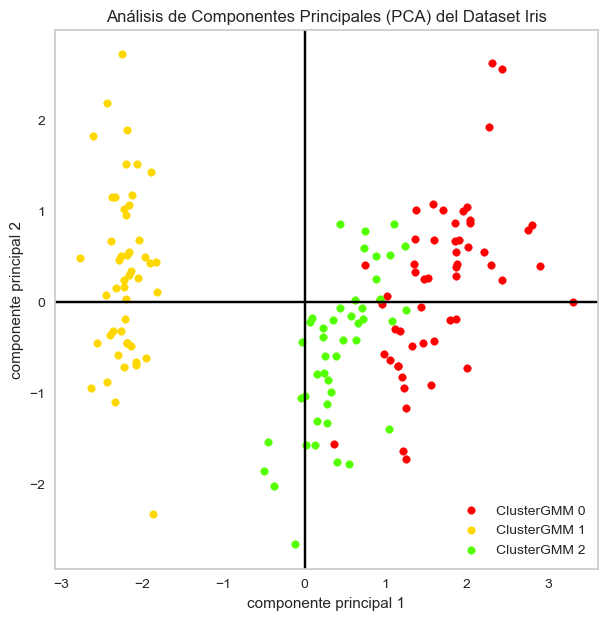

In [23]:
# Creamos un nuevo DataFrame con los datos de PCA y los clusters obtenidos por SC
finalDf_gmm = pd.concat([X_pca, data[['target']]], axis = 1)
finalDf_gmm['ClusterGMM'] = y_gmm

# Visualizamos los resultados
plotData(finalDf_gmm, 'ClusterGMM')

## 2.- Comparar PCA VS CLUSTERING

In [24]:
from sklearn.metrics import accuracy_score

In [25]:
#Vamos a mapear los datos originales para comparar con los clusteres obtenidos
mapa = {'Iris-setosa': 1, 'Iris-versicolor': 2, 'Iris-virginica': 0}
finalDf['target_mapped'] = finalDf['target'].map(mapa)

#Comparamos los resultados predichos con los originales
aciertos1 = sum(finalDf['ClusterKmeans'] == finalDf['target_mapped'])
precision1 = aciertos1 / len(finalDf)

precision1

0.5

In [26]:
finalDf.sample(10)

,componente principal 1,componente principal 2,target,ClusterKmeans,target_mapped
39,-2.170547,0.292727,Iris-setosa,1,1
20,-1.914556,0.430465,Iris-setosa,1,1
123,1.329194,-0.486761,Iris-virginica,0,0
84,0.221417,-0.280848,Iris-versicolor,0,2
83,1.056691,-0.636901,Iris-versicolor,0,2
66,0.348006,-0.190622,Iris-versicolor,0,2
13,-2.639716,-0.938282,Iris-setosa,1,1
129,1.864778,0.555382,Iris-virginica,2,0
141,1.903117,0.686025,Iris-virginica,2,0
23,-1.820412,0.106751,Iris-setosa,1,1


In [27]:
#Consultamos con los resultados sin realizar PCA
pred_data['target'] = y.map(mapa)
aciertos2 = sum(pred_data['pred_group'] == pred_data['target'])
precision2 = aciertos2 / len(pred_data)

precision2


0.8333333333333334

In [28]:
pred_data.sample(10)

,sepal length,sepal width,petal length,petal width,pred_group,target
37,-1.143017,0.106445,-1.284407,-1.444450,1,1
71,0.310998,-0.587764,0.137236,0.133226,2,2
132,0.674501,-0.587764,1.047087,1.316483,0,0
136,0.553333,0.800654,1.047087,1.579429,0,0
52,1.280340,0.106445,0.649027,0.396172,0,2
7,-1.021849,0.800654,-1.284407,-1.312977,1,1
125,1.643844,0.337848,1.274550,0.790591,0,0
85,0.189830,0.800654,0.421564,0.527645,0,2
131,2.492019,1.726266,1.502013,1.053537,0,0
28,-0.779513,0.800654,-1.341272,-1.312977,1,1


In [29]:
# Remapeamos los datos originales para comparar con los clusters obtenidos por GaussianMixture
mapa = {'Iris-setosa': 1, 'Iris-versicolor': 2, 'Iris-virginica': 0}

# Evaluamos los resultados empleando GaussianMixture


finalDf_gmm['target_mapped'] = finalDf_gmm['target'].map(mapa)
aciertos3 = sum(finalDf_gmm['ClusterGMM'] == finalDf_gmm['target_mapped'])
precision3 = aciertos3 / len(finalDf_gmm)
precision3

0.9666666666666667

In [30]:
# Calculamos el recall
from sklearn.metrics import recall_score

# Evaluamos el recall de los modelos
recall1 = recall_score(finalDf['target_mapped'], finalDf['ClusterKmeans'], average='weighted')
recall2 = recall_score(pred_data['target'], pred_data['pred_group'], average='weighted')
recall3 = recall_score(finalDf_gmm['target_mapped'], finalDf_gmm['ClusterGMM'], average='weighted')

# Mostramos los resultados
print("Recall KMeans: ", recall1)
print("Recall KMeans sin PCA: ", recall2)
print("Recall GaussianMixture: ", recall3)

Recall KMeans:  0.5
Recall KMeans sin PCA:  0.8333333333333334
Recall GaussianMixture:  0.9666666666666667


In [31]:
finalDf_gmm.sample(10)

,componente principal 1,componente principal 2,target,ClusterGMM,target_mapped
131,2.316082,2.626184,Iris-virginica,0,0
149,0.959299,-0.022284,Iris-virginica,0,0
27,-2.168194,0.552016,Iris-setosa,1,1
60,-0.124697,-2.658063,Iris-versicolor,2,2
87,1.035878,-1.392466,Iris-versicolor,2,2
8,-2.341958,-1.095146,Iris-setosa,1,1
80,0.121534,-1.563592,Iris-versicolor,2,2
3,-2.304197,-0.575368,Iris-setosa,1,1
109,2.267555,1.921443,Iris-virginica,0,0
81,0.014118,-1.573392,Iris-versicolor,2,2


---------------------------------------------------------------
En este caso, vemos que tras la PCA reducimos de cuatro a dos variables, y como podemos comprobar en los casos anteriores, la precisión de la clasificación realizada empleando el mismo algoritmo se reduce drásticamente tras aplicar el proceso de PCA, lo que implica que ha habido pérdida de información en el proceso, lo que nos indicaría que a pesar de la reducción de dimensionalidad, esta no sería recomendable.

Como vemos en los subconjuntos establecidos, la variedad iris-setosa es fácilmente identificable por el algoritmo dado que sus características están suficientemente diferenciadas respecto a las otras dos, sin embargo entre las variedades virgínica y versicolor al algoritmo de Kmeans le cuesta diferenciar, con o sin proceso de PCA previo, dado que existen muchas similitudes entre las variedades, observándose numerosos especímenes con características que permitirían catalogarlas como cualquiera de las dos, al menos en lo que a los datos referentes al tamaño de pétalos y sépalos se refiere.

Si ibservamos la representación gráfica tras la PCA, que al reducirlo a dos variables facilita su visualización, vemos como el algoritmo de Kmeans realiza un corte limpio entre los dos grupos a partir de ambas componentes principales, separando completamente los grupos dentro del nuevo espacio creado. En cambio, al representar los datos reales, vemos como existe un espacio intermedio donde aparecen especímenes de las dos variedades intercaladas, siendo esta la zona clara de error en la clasificación, lo que nos indica que podríamos probar un algoritmo diferente a Kmeans que pudiera entender figuras más complejas.

Por ende, he entrenado un segundo modelo de clustering, conocido como GaussianMixture, que emplea un algoritmo diferente a Kmeans para agrupar, de modo que podamos probar si es capaz de separar grupos más complejos, como es el caso. Como podemos comprobar vista la precisión obtenida a partir del modelo gaussiano, mientras k-means no podía interpretar adecuadamente los datos tras realizar la reducción a las componentes principales, GaussianMixture mejora enormemente el resultado frente a la aplicación de K-means sobre el conjunto de datos original, obteniendo unos valores de precisión y recall muy elevados, lo que demostraría en este caso que se trata de un modelo de clasificación bastante fiable para este problema.

---------------------------------------------------------------

## 3.- Discusión sobre la presencia de OUTLIERS

In [32]:
# Detección de outliers
from sklearn.ensemble import IsolationForest

#Instanciamos el modelo IsolationForest
outliers_fraction = 0.05
model = IsolationForest(contamination = outliers_fraction, random_state=seed, n_estimators= 500, max_features= 1.0, bootstrap=False)

#Entrenamos el modelo en los datos transformados por PCA
model.fit(X_pca)

#Predecimos los valores atípicos en los datos transformados por PCA
outliers = model.predict(X_pca)

#Añadimos la columna de outliers al DataFrame
finalDf['outliers'] = outliers


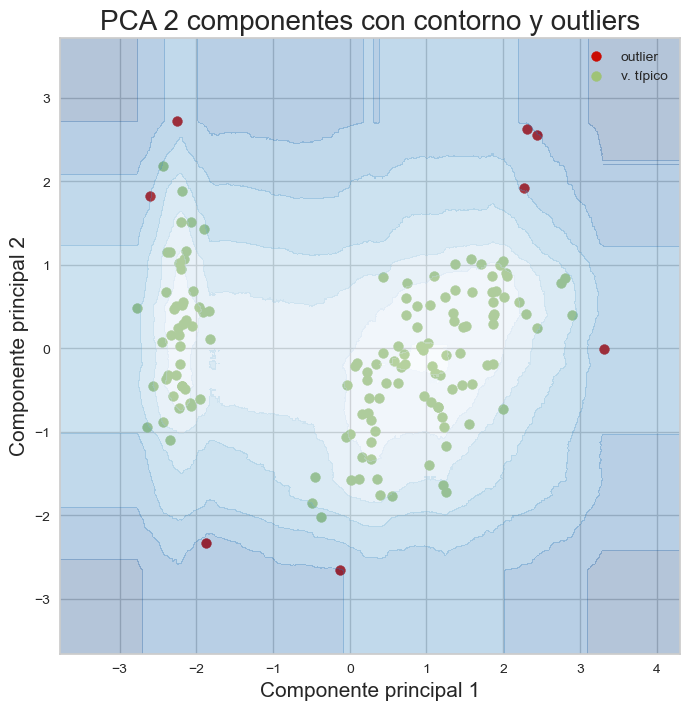

In [33]:
# Visualizamos los datos tras PCA y los outliers detectados

# Creamos la figura
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel('Componente principal 1', fontsize=15)
ax.set_ylabel('Componente principal 2', fontsize=15)
ax.set_title('PCA 2 componentes con contorno y outliers', fontsize=20)

# Dibujamos los puntos del conjunto de datos, distinguiendo entre outliers y valores típicos
targets = [-1, 1]
colors = ['r', 'g']
for target, color in zip(targets, colors):
    indicesToKeep = finalDf['outliers'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'componente principal 1'],
            finalDf.loc[indicesToKeep, 'componente principal 2'],
            c=color, s=50, label='outlier' if target == -1 else 'v. típico')

# Creamos el grid para dibujar el contorno
x_min, x_max = X_pca['componente principal 1'].min() - 1, X_pca['componente principal 1'].max() + 1
y_min, y_max = X_pca['componente principal 2'].min() - 1, X_pca['componente principal 2'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                    np.arange(y_min, y_max, 0.01))

# Evaluamos los valores atípicos en el grid
Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Dibujamos el contorno y mostramos la figura
ax.contourf(xx, yy, Z, cmap=plt.cm.Blues_r, alpha=0.3)
ax.legend()
plt.show()

In [34]:
# Analisis de los outliers univariate

#Instanciamos el modelo IsolationForest
outliers_fraction = 0.05
model_cp1 = IsolationForest(contamination = outliers_fraction, random_state=seed, n_estimators= 500, max_features= 1.0, bootstrap=False)
model_cp2 = IsolationForest(contamination = outliers_fraction, random_state=seed, n_estimators= 500, max_features= 1.0, bootstrap=False)

#Entrenamos el modelo en los datos de la componente principal 1
model_cp1.fit(X_pca[['componente principal 1']])
#Entrenamos el modelo en los datos de la componente principal 2
model_cp2.fit(X_pca[['componente principal 2']])

# Predecimos los valores atípicos en los datos de la componente principal 1
outliers_cp1 = model_cp1.predict(X_pca[['componente principal 1']])

# Predecimos los valores atípicos en los datos de la componente principal 2
outliers_cp2 = model_cp2.predict(X_pca[['componente principal 2']])

# Añadimos las columnas de outliers al DataFrame
finalDf['outliers_cp1'] = outliers_cp1
finalDf['outliers_cp2'] = outliers_cp2

In [36]:
# Visualizamos los datos tras PCA y los outliers detectados

# Creamos la figura
sns.boxplot(finalDf['componente principal 1'], kde=True, color='blue', hue= 'outliers_cp1',  bins=30)

ValueError: The following variable cannot be assigned with wide-form data: `hue`

----------------------------------------------------------------
En la gráfica previa podemos ver todos aquellos elementos que, establecido un margen de confianza del 95%, se considerarían outliers en una evaluación multivariante. Este proceso se ha realizado empleando las componentes principales tras la reducción de dimensionalidad establecida por PCA, lo que nos indica que estos son los elementos que más se distancian en estas dos componentes de los subconjuntos identificados.

En este caso podemos considerar estos outliers como casos atípicos pero reales de las diferentes variedades de Iris, dado que, si bien están alejados de los tres subconjuntos, no se encuentran valores altamente discrepantes. si nos fijamos en los contornos establecidos, vemos que si bien quedan fuera del nivel de confianza que hemos establecido, no se aprecia una distancia especialmente alarmante, como para considerar que los datos sean erroneos.

----------------------------------------------------------------